# Materials Atlas — Linear Algebra for Computational Materials Science

**The geometric language behind computational science.** This notebook builds intuition for the vectors, transformations, and systems that recur throughout the Atlas.

- **Estimated duration:** 2–3 hours
- **Prerequisites:** `00-python-environment.ipynb`; basic NumPy and Matplotlib familiarity
- **Required packages:** NumPy, Matplotlib

> The goal is not to memorize procedures. It is to see what the mathematics is doing, then use computation to make that picture concrete.

## Learning objectives

By the end, you will be able to:

- distinguish scalars, vectors, and matrices;
- describe vectors geometrically and compute their basic operations with NumPy;
- view matrices as transformations rather than merely tables of numbers;
- solve a linear system with `numpy.linalg.solve`;
- explain determinants as area, volume, and orientation changes;
- describe eigenvectors as special directions and eigenvalues as their stretch factors;
- recognize why linear algebra appears throughout computational materials science.

## 1. Why linear algebra?

Computational materials science is full of quantities with direction, collections of coupled quantities, and transformations between coordinate systems. Linear algebra is the compact language for all three.

- A **stress tensor** relates a surface direction to a force direction.
- **Crystal symmetry** transforms one arrangement of atoms into an equivalent one.
- **Density Functional Theory (DFT)** solves large eigenvalue problems.
- **Molecular dynamics** updates many position and force vectors.
- **Finite elements** and **phase-field** methods solve large linear systems.
- **Machine learning** represents data and model parameters with vectors and matrices.

The same ideas appear at different scales. Learning them once gives you a reusable mental model.

```mermaid
flowchart LR

L[Linear Algebra]
C[Crystal Geometry]
S[Stress and Strain]
D[Electronic Structure]
M[Molecular Dynamics]
P[Phase-Field]
I[Materials Informatics]

L --> C
L --> S
L --> D
L --> M
L --> P
L --> I
```

This diagram answers one question: **where does this mathematical language return?** The applications differ, but they share vectors, matrices, and linear systems.

## 2. Scalars

### Intuition

A scalar is a quantity with magnitude only. A temperature of 300 K does not point north or east; neither does an energy of 2 eV or a pressure of 1 atm. Scalars are the simplest numerical descriptions in science.

### Mathematics

We usually write a scalar as an italic lower-case symbol, such as $T$ for temperature or $E$ for energy. A scalar can multiply a vector, changing its size without changing its direction (unless the scalar is negative).

In [1]:
temperature_kelvin = 300.0
energy_eV = -3.42
pressure_GPa = 2.5

print(f"Temperature: {temperature_kelvin} K")
print(f"Energy: {energy_eV} eV")
print(f"Pressure: {pressure_GPa} GPa")

Temperature: 300.0 K
Energy: -3.42 eV
Pressure: 2.5 GPa


### Experiment

Change one value and its unit label together. Units are not decoration: they tell you what a number represents.

### Reflection

Which properties in a materials database are scalars? Which would need a direction or orientation?

### Materials Atlas Connection

Temperature and free energy are scalars in thermodynamics (Module 03). Later, scalar fields such as composition will vary from point to point in phase-field models (Module 10).

## 3. Vectors

### Intuition

A vector has **magnitude** and **direction**. Imagine an arrow from the origin: its endpoint says where it points, and its length says how large it is. A displacement from one atom to another, a force on an atom, and a crystal lattice direction are all natural vectors.

### Mathematics

In two dimensions, a vector is written as $\mathbf{v} = [v_x, v_y]^T$. Its length (or norm) is $\|\mathbf{v}\| = \sqrt{v_x^2 + v_y^2}$. The coordinates depend on the chosen axes; the geometric arrow does not.

Force vector: [3. 2.]
Magnitude: 3.61


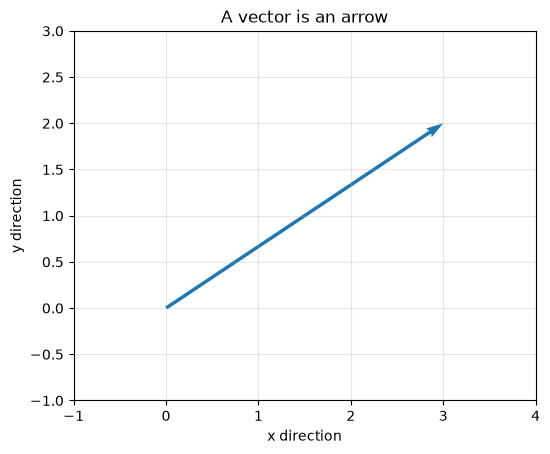

In [2]:
import numpy as np
import matplotlib.pyplot as plt

force = np.array([3.0, 2.0])
print("Force vector:", force)
print(f"Magnitude: {np.linalg.norm(force):.2f}")

fig, ax = plt.subplots()
ax.quiver(0, 0, force[0], force[1], angles="xy", scale_units="xy", scale=1, color="tab:blue")
ax.set(xlim=(-1, 4), ylim=(-1, 3), xlabel="x direction", ylabel="y direction", title="A vector is an arrow")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.show()

### Experiment

Try `[1, 3]`, then `[-3, 2]`. Predict the arrow before you run the cell. Which coordinate changes the horizontal component?

### Reflection

If two coordinate systems use different axes, can the coordinates of a vector change while the physical force remains the same?

### Materials Atlas Connection

Lattice vectors in crystallography (Module 05), forces in molecular dynamics (Module 08), and reciprocal-space directions in DFT (Module 07) all use this geometry.

## 4. Vector operations

### Intuition

Vector addition places one displacement after another. Subtraction asks for the displacement between endpoints. Scalar multiplication lengthens, shortens, or reverses an arrow. The dot product measures alignment; the cross product creates a perpendicular direction; a projection extracts the part of one vector that points along another.

In [3]:
a = np.array([2.0, 1.0])
b = np.array([1.0, 2.0])

print("a + b =", a + b)
print("a - b =", a - b)
print("2a =", 2 * a)
print("a · b =", np.dot(a, b))
print("a × b (in 3D) =", np.cross(np.append(a, 0), np.append(b, 0)))
print("||a|| =", np.linalg.norm(a))

projection_of_a_on_b = (np.dot(a, b) / np.dot(b, b)) * b
print("projection of a onto b =", projection_of_a_on_b)

a + b = [3. 3.]
a - b = [ 1. -1.]
2a = [4. 2.]
a · b = 4.0
a × b (in 3D) = [0. 0. 3.]
||a|| = 2.23606797749979
projection of a onto b = [0.8 1.6]


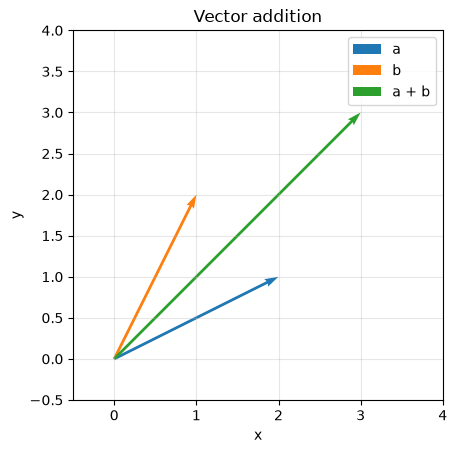

In [4]:
fig, ax = plt.subplots()
for vector, label, color in [(a, "a", "tab:blue"), (b, "b", "tab:orange"), (a + b, "a + b", "tab:green")]:
    ax.quiver(0, 0, vector[0], vector[1], angles="xy", scale_units="xy", scale=1, color=color, label=label)
ax.set(xlim=(-0.5, 4), ylim=(-0.5, 4), xlabel="x", ylabel="y", title="Vector addition")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Mathematics

The dot product is $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta$. It is large and positive for aligned vectors, zero for perpendicular vectors, and negative for opposing vectors. The 3D cross product $\mathbf{a} \times \mathbf{b}$ is perpendicular to both inputs; its magnitude is the area of their parallelogram.

### Experiment

Make `a` and `b` perpendicular. What happens to their dot product? Make them parallel. What happens to the cross product?

### Reflection

Why would an alignment measurement be useful when comparing an atomic displacement with a force?

### Materials Atlas Connection

Dot products measure projections and angles in crystal geometry. Cross products compute surface normals and cell volumes. Norms measure force magnitudes in molecular dynamics.

## 5. Matrices are transformations

### Intuition

A matrix can be read as a table of numbers, but its more useful interpretation is a **machine that transforms vectors**. Feed in an arrow; receive a new arrow. The transformation may rotate, scale, reflect, or shear space.

### Mathematics

A two-dimensional transformation maps $\mathbf{x}$ to $A\mathbf{x}$. The columns of $A$ tell you where the unit basis arrows land. This is why a matrix describes an entire coordinate system transformation, not just one point.

In [5]:
theta = np.deg2rad(35)
rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
scaling = np.array([[1.6, 0.0], [0.0, 0.7]])
reflection = np.array([[-1.0, 0.0], [0.0, 1.0]])
shear = np.array([[1.0, 0.8], [0.0, 1.0]])

point = np.array([1.0, 1.0])
for name, matrix in [("rotation", rotation), ("scaling", scaling), ("reflection", reflection), ("shear", shear)]:
    print(f"{name:10s}: {matrix @ point}")

rotation  : [0.24557561 1.39272848]
scaling   : [1.6 0.7]
reflection: [-1.  1.]
shear     : [1.8 1. ]


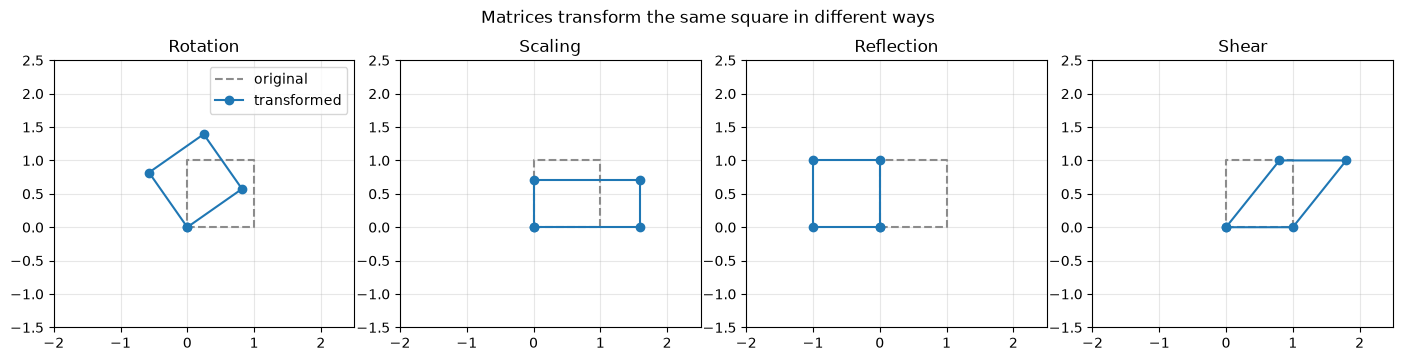

In [6]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)
transformations = [("Rotation", rotation), ("Scaling", scaling), ("Reflection", reflection), ("Shear", shear)]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (name, matrix) in zip(axes, transformations):
    transformed = square @ matrix.T
    ax.plot(square[:, 0], square[:, 1], "--", color="0.55", label="original")
    ax.plot(transformed[:, 0], transformed[:, 1], marker="o", label="transformed")
    ax.set(title=name, xlim=(-2, 2.5), ylim=(-1.5, 2.5))
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
axes[0].legend()
fig.suptitle("Matrices transform the same square in different ways")
fig.tight_layout()
plt.show()

### Experiment

Change the angle, the scale factors, or the shear entry. Which changes preserve the square's area? Which reverse its orientation?

### Reflection

Why is “matrix as transformation” a more useful mental model than “matrix as spreadsheet”?

### Materials Atlas Connection

Crystal symmetry operations and strain transformations act on coordinates in exactly this way. The difference is that real structures may contain millions of coordinates instead of four square corners.

## 6. Matrix multiplication: composing actions

### Intuition

Applying a rotation and then a shear is a two-step transformation. Matrix multiplication combines those steps into one matrix. Order matters: rotating then shearing is generally not the same as shearing then rotating.

### Mathematics

For matrices $A$ and $B$, the product $AB$ means “apply $B$ first, then apply $A$.” Each entry comes from a row of $A$ interacting with a column of $B$, but the important picture is composition.

In [7]:
rotate_then_shear = shear @ rotation
shear_then_rotate = rotation @ shear

print("Shear after rotation:\n", rotate_then_shear)
print("\nRotation after shear:\n", shear_then_rotate)
print("\nAre they equal?", np.allclose(rotate_then_shear, shear_then_rotate))

Shear after rotation:
 [[1.27801319 0.0817452 ]
 [0.57357644 0.81915204]]

Rotation after shear:
 [[0.81915204 0.0817452 ]
 [0.57357644 1.27801319]]

Are they equal? False


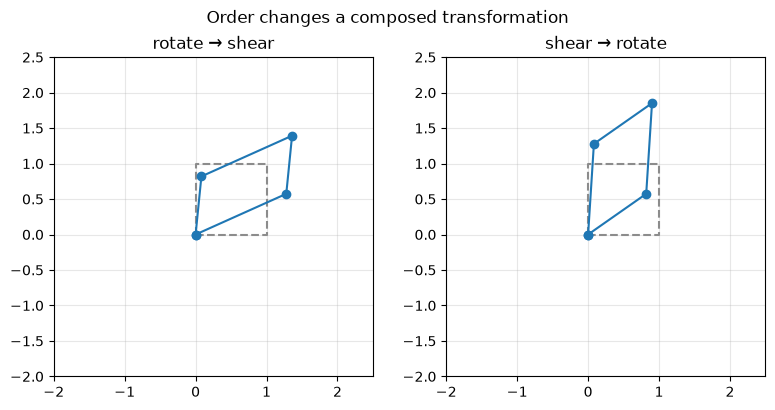

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (name, matrix) in zip(axes, [("rotate → shear", rotate_then_shear), ("shear → rotate", shear_then_rotate)]):
    transformed = square @ matrix.T
    ax.plot(square[:, 0], square[:, 1], "--", color="0.55")
    ax.plot(transformed[:, 0], transformed[:, 1], marker="o")
    ax.set(title=name, xlim=(-2, 2.5), ylim=(-2, 2.5))
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
fig.suptitle("Order changes a composed transformation")
fig.tight_layout()
plt.show()

### Experiment

Swap the multiplication order in one plot. What visual difference do you expect?

### Materials Atlas Connection

Coordinate rotations, deformation gradients, and sequences of symmetry operations are compositions. Keeping the order explicit avoids subtle and costly geometry errors.

## 7. Linear systems: finding the unknown

### Intuition

A linear system combines several constraints to determine unknown values. Imagine two rules that must both be satisfied: their intersection is the solution. In simulation, the unknowns may be displacements, temperatures, electrostatic potentials, or expansion coefficients.

### Mathematics

The compact form is $A\mathbf{x}=\mathbf{b}$. Here $A$ encodes how unknowns are coupled, $\mathbf{x}$ is what we seek, and $\mathbf{b}$ is the known outcome or forcing.

In [9]:
A = np.array([[2.0, 1.0], [1.0, 3.0]])
b_rhs = np.array([5.0, 6.0])
solution = np.linalg.solve(A, b_rhs)

print("Solution x =", solution)
print("Check A @ x =", A @ solution)
print("Target b =", b_rhs)

Solution x = [1.8 1.4]
Check A @ x = [5. 6.]
Target b = [5. 6.]


`np.linalg.solve(A, b)` is preferred to computing $A^{-1}\mathbf{b}$. A solver directly answers the question and is usually more efficient and numerically reliable. Explicit inverses are occasionally useful analytically, but they are rarely the right first computational tool.

### Experiment

Change `b_rhs`, solve again, and verify the check. Then change one entry of `A`; does the solution move as you expected?

### Reflection

Why is solving for the unknown more valuable than constructing every detail of an inverse transformation?

### Materials Atlas Connection

Finite-element equilibrium, diffusion discretizations, and electronic-structure methods all reduce important steps to systems far larger than this two-by-two example.

## 8. Determinants: transformed area, volume, and orientation

### Intuition

A determinant measures how a transformation changes area in 2D or volume in 3D. A determinant of 2 doubles area; a determinant of 0 collapses a shape into a line or point; a negative determinant flips orientation.

### Mathematics

For a two-by-two matrix $A$, $\det(A)$ is its signed area scale factor. A zero determinant means the matrix is **singular**: some distinct input directions have been collapsed together, so the transformation cannot be undone.

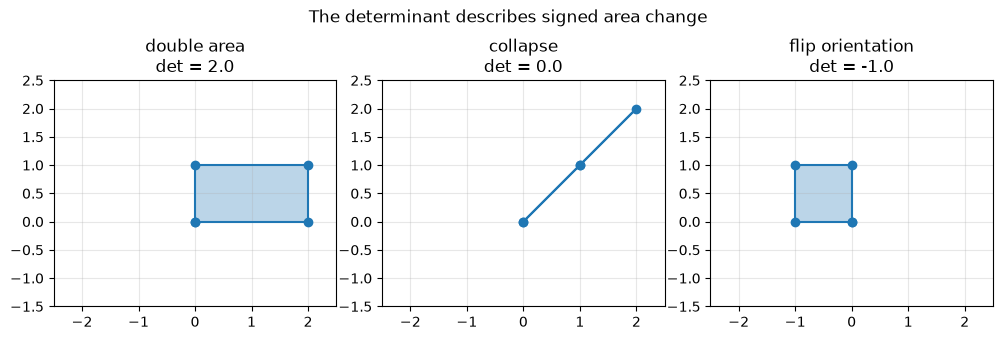

In [10]:
area_cases = [("double area", np.array([[2.0, 0.0], [0.0, 1.0]])), ("collapse", np.array([[1.0, 1.0], [1.0, 1.0]])), ("flip orientation", reflection)]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, (name, matrix) in zip(axes, area_cases):
    transformed = square @ matrix.T
    ax.fill(transformed[:, 0], transformed[:, 1], alpha=0.3)
    ax.plot(transformed[:, 0], transformed[:, 1], marker="o")
    ax.set(title=f"{name}\ndet = {np.linalg.det(matrix):.1f}", xlim=(-2.5, 2.5), ylim=(-1.5, 2.5))
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
fig.suptitle("The determinant describes signed area change")
fig.tight_layout()
plt.show()

### Experiment

Alter the diagonal scaling matrix. Can you construct one with determinant 1 that visibly changes the square's shape but not its area?

### Materials Atlas Connection

A determinant connects lattice vectors to unit-cell volume and deformation gradients to volume change. A singular matrix warns that a system has lost independent information.

## 9. Eigenvalues and eigenvectors

### Intuition

Most directions change direction when a matrix acts on them. An **eigenvector** is special: it keeps its direction, although it may stretch, compress, or reverse. The associated **eigenvalue** tells you by what factor.

Think of repeatedly deforming a material sample. Eigenvectors identify the directions that remain aligned with the deformation; eigenvalues say how strongly those directions change. This is why they reveal principal stresses, normal modes, and electronic states.

### Mathematics

The defining equation is $A\mathbf{v}=\lambda\mathbf{v}$. The scalar $\lambda$ is an eigenvalue and the nonzero vector $\mathbf{v}$ is its eigenvector. This is not saying the vector is unchanged—only that its *direction* is preserved, up to reversal when $\lambda$ is negative.

In [11]:
deformation = np.array([[3.0, 1.0], [1.0, 2.0]])
eigenvalues, eigenvectors = np.linalg.eig(deformation)
# This symmetric real matrix has real eigenpairs; make that fact explicit for plotting.
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real

print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)
for value, vector in zip(eigenvalues, eigenvectors.T):
    print("A @ v equals λv?", np.allclose(deformation @ vector, value * vector))

Eigenvalues: [3.61803399+0.j 1.38196601+0.j]
Eigenvectors (columns):
 [[ 0.85065081+0.j -0.52573111+0.j]
 [ 0.52573111+0.j  0.85065081+0.j]]
A @ v equals λv? True
A @ v equals λv? True


/private/tmp/materials-atlas-notebook-check/lib/python3.14/site-packages/matplotlib/transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


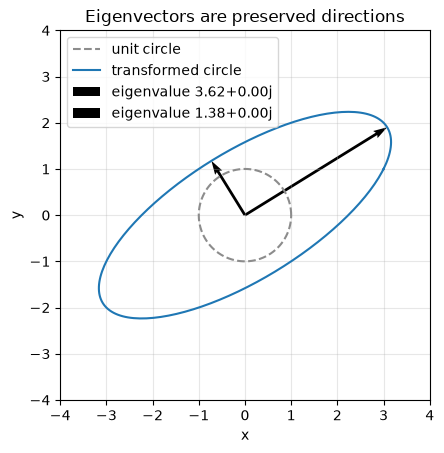

In [12]:
unit_circle_angle = np.linspace(0, 2 * np.pi, 200)
unit_circle = np.column_stack((np.cos(unit_circle_angle), np.sin(unit_circle_angle)))
transformed_circle = unit_circle @ deformation.T
fig, ax = plt.subplots()
ax.plot(unit_circle[:, 0], unit_circle[:, 1], "--", color="0.55", label="unit circle")
ax.plot(transformed_circle[:, 0], transformed_circle[:, 1], label="transformed circle")
for value, vector in zip(eigenvalues, eigenvectors.T):
    arrow = value * vector
    ax.quiver(0, 0, arrow[0], arrow[1], angles="xy", scale_units="xy", scale=1, label=f"eigenvalue {value:.2f}")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="x", ylabel="y", title="Eigenvectors are preserved directions")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Experiment

Modify the symmetric `deformation` matrix and rerun both cells. Watch the ellipse and the special directions. A symmetric matrix is a useful first case because its eigenvectors are real and perpendicular.

### Reflection

Why are eigenvectors more informative than just listing all transformed points? Which physical directions would you want to identify in a stressed crystal?

### Materials Atlas Connection

Principal stresses and strains use eigenvectors. Phonons are vibration eigenmodes. DFT solves Hamiltonian eigenproblems. Principal component analysis (PCA) finds informative data directions in materials informatics.

## 10. Singular value decomposition (SVD)

### Intuition

SVD describes any matrix as three simple actions: rotate or reflect, stretch independently along perpendicular directions, then rotate or reflect again. The stretch factors are the **singular values**. Unlike eigenvectors, this picture works cleanly even for rectangular data matrices.

You do not need the derivation yet. Keep the image: SVD finds the main directions and strengths of a transformation or dataset.

In [13]:
data_map = np.array([[2.0, 1.0], [0.5, 1.5], [1.0, 0.0]])
U, singular_values, Vt = np.linalg.svd(data_map, full_matrices=False)
print("Singular values:", singular_values)
print("Reconstruction matches data?", np.allclose(data_map, U @ np.diag(singular_values) @ Vt))

Singular values: [2.67883836 1.15057595]
Reconstruction matches data? True


### Reflection

If one singular value is much larger than the others, what does that suggest about the dominant direction in the data?

### Materials Atlas Connection

SVD supports dimensionality reduction, noise filtering, and data compression—important tools for high-dimensional characterization and materials-informatics datasets (Modules 11–12).

## 11. Computational materials science connections

| Linear algebra concept | Materials-science application | Future Atlas module |
| --- | --- | --- |
| Scalars | temperature, energy, pressure, free energy | 03 — Thermodynamics |
| Vectors and dot products | lattice directions, forces, bond angles | 05 — Crystallography; 08 — Molecular Dynamics |
| Matrices | stress/strain tensors and symmetry operations | 05 — Crystallography; 06 — Electronic Structure |
| Linear systems | equilibrium, diffusion, discretized fields | 09 — CALPHAD; 10 — Phase-Field |
| Determinants | unit-cell volume and deformation | 05 — Crystallography |
| Eigenvalues/eigenvectors | Hamiltonians, phonons, principal stresses | 07 — DFT; 08 — Molecular Dynamics |
| SVD | feature reduction and noisy experimental data | 11 — Materials Informatics; 12 — Machine Learning |

The table is a map, not a checklist. Revisit it when a later notebook introduces an unfamiliar method.

## 12. Mini project — Crystal Transformation Explorer

A crystal lattice can be represented as a collection of atomic position vectors. In this project, you will apply matrix transformations to a small square lattice and observe the coordinate changes.

1. Run the scaffold.
2. Change the rotation angle, scale factors, shear, or reflection.
3. Describe the transformation in a Markdown cell: which matrix action did you choose, and what happened to the spacing, orientation, and area?
4. Restart the Kernel and use **Run All** to reproduce the figure.

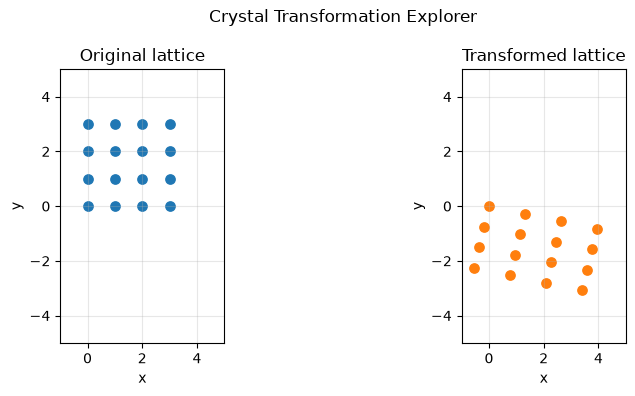

Determinant (area scale factor): -1.040


In [14]:
# Atomic positions for a simple 2D square lattice.
grid_x, grid_y = np.meshgrid(np.arange(4), np.arange(4))
atomic_positions = np.column_stack((grid_x.ravel(), grid_y.ravel())).astype(float)

# Edit these matrices to explore crystal transformations.
project_angle = np.deg2rad(20)
project_rotation = np.array([[np.cos(project_angle), -np.sin(project_angle)], [np.sin(project_angle), np.cos(project_angle)]])
project_scaling = np.array([[1.3, 0.0], [0.0, 0.8]])
project_shear = np.array([[1.0, 0.35], [0.0, 1.0]])
project_reflection = np.array([[1.0, 0.0], [0.0, -1.0]])
project_transform = project_reflection @ project_shear @ project_scaling @ project_rotation
transformed_positions = atomic_positions @ project_transform.T

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(atomic_positions[:, 0], atomic_positions[:, 1], s=45)
axes[0].set(title="Original lattice", xlabel="x", ylabel="y", xlim=(-1, 5), ylim=(-5, 5))
axes[1].scatter(transformed_positions[:, 0], transformed_positions[:, 1], s=45, color="tab:orange")
axes[1].set(title="Transformed lattice", xlabel="x", ylabel="y", xlim=(-1, 5), ylim=(-5, 5))
for ax in axes:
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
fig.suptitle("Crystal Transformation Explorer")
fig.tight_layout()
plt.show()

print(f"Determinant (area scale factor): {np.linalg.det(project_transform):.3f}")

## 13. Reflection

Answer these in your own words before moving on:

1. Why are eigenvectors special directions?
2. Why is solving $A\mathbf{x}=\mathbf{b}$ usually more useful than computing $A^{-1}$?
3. How does viewing matrices as transformations change how you read matrix multiplication?
4. What does a zero determinant tell you about a transformation?
5. Which future materials topic now feels less mysterious because you can name its linear-algebra ingredients?

If an answer feels vague, return to the relevant visualization and alter one value. A good question is often the best reason to run a cell again.

## 14. Continue with

Continue to **[02-atomic-bonding.ipynb](02-atomic-bonding.ipynb)**. Linear algebra gives you the language of vectors and transformations; atomic bonding uses that language to explain how atoms interact, settle into stable arrangements, and give materials their physical properties.